In [1]:
print("Hello")

Hello


# Load the bitcoin.csv to a dataframe

In [7]:
import pandas as pd
df = pd.read_csv('bitcoin.csv')
display(df)

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
...,...,...,...,...,...,...,...
4994,22-07-2010,0.1,0.1,0.1,0.1,2.16K,0.00%
4995,21-07-2010,0.1,0.1,0.1,0.1,0.58K,0.00%
4996,20-07-2010,0.1,0.1,0.1,0.1,0.26K,0.00%
4997,19-07-2010,0.1,0.1,0.1,0.1,0.57K,0.00%


#	Sort data by date

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df_sorted = df.sort_values(by='Date')
display(df_sorted)

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,0.08K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%
...,...,...,...,...,...,...,...
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%


#	Handle missing values in the dataframe

In [15]:
# Clean and convert 'Price', 'Open', 'High', 'Low', 'Vol.', and 'Change %' to numeric
for col in ['Price', 'Open', 'High', 'Low']:
    if df_sorted[col].dtype == 'object':
        df_sorted[col] = df_sorted[col].str.replace(',', '', regex=False).astype(float)
df_sorted

,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.00
4997,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.00
4996,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00
4995,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00
4994,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00
...,...,...,...,...,...,...,...
4,2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35
3,2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46
2,2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62
1,2024-03-23,64037.8,63785.6,65972.4,63074.9,35110.0,0.40


In [18]:
# Handle 'Vol.' column: remove 'K' and convert to float
# First, identify non-numeric values that are not 'K' or '.' for 'Vol.' and 'Change %'
def clean_vol_change(df_col):
    if isinstance(df_col, str):
        if 'K' in df_col:
            return float(df_col.replace('K', '')) * 1000
        elif 'M' in df_col:
            return float(df_col.replace('M', '')) * 1000000
        elif 'B' in df_col:
            return float(df_col.replace('B', '')) * 1000000000
        elif '%' in df_col:
            return float(df_col.replace('%', ''))
        else:
            try:
                return float(df_col.replace(',', ''))
            except ValueError:
                return None
    return df_col

df_sorted['Vol.'] = df_sorted['Vol.'].apply(clean_vol_change)
# The 'Change %' column is already numeric from a previous cleaning step (e.g., cell Y3oWmBgXoX_A),
# so applying .str accessor here would cause an AttributeError.

In [20]:
# Check for any remaining missing values
print("Missing values after all cleaning and imputation steps:")
display(df_sorted.isnull().sum())

Missing values after all cleaning and imputation steps:


,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0



#	Scale features using MinMaxScaler


In [21]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical columns to scale (excluding 'Date')
features_to_scale = ['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the selected features
df_scaled_features = scaler.fit_transform(df_sorted[features_to_scale])

# Create a new DataFrame with the scaled features
df_scaled = pd.DataFrame(df_scaled_features, columns=features_to_scale)

# If you want to include the 'Date' column in the scaled DataFrame:
df_scaled['Date'] = df_sorted['Date'].reset_index(drop=True)
df_scaled = df_scaled[['Date'] + features_to_scale] # Reorder columns to have Date first

print("Scaled DataFrame head:")
display(df_scaled.head())


Scaled DataFrame head:


,Date,Price,Open,High,Low,Vol.,Change %
0,2010-07-18,0.0,0.000000,0.0,0.000001,0.000000,0.145185
1,2010-07-19,0.0,0.000001,0.0,0.000001,0.000490,0.145185
2,2010-07-20,0.0,0.000001,0.0,0.000001,0.000180,0.145185
3,2010-07-21,0.0,0.000001,0.0,0.000001,0.000500,0.145185
4,2010-07-22,0.0,0.000001,0.0,0.000001,0.002081,0.145185


#	Train-test split using time-based split (no shuffling)

In [22]:
# Define the split ratio (e.g., 80% for training, 20% for testing)
split_ratio = 0.8
split_index = int(len(df_scaled) * split_ratio)

# Split the DataFrame into training and testing sets
train_df = df_scaled.iloc[:split_index]
test_df = df_scaled.iloc[split_index:]

# Define features (X) and target (y)
# Assuming 'Price' is the target variable
features = [col for col in df_scaled.columns if col not in ['Date', 'Price']]
target = 'Price'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Training set size: {len(train_df)} rows")
print(f"Testing set size: {len(test_df)} rows")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Display the head of the training and testing target variables for verification
print("\ny_train head:")
display(y_train.head())
print("\ny_test head:")
display(y_test.head())


Training set size: 3999 rows
Testing set size: 1000 rows
X_train shape: (3999, 5), y_train shape: (3999,)
X_test shape: (1000, 5), y_test shape: (1000,)

y_train head:


,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0



y_test head:


,Price
3999,0.490440
4000,0.479384
4001,0.459084
4002,0.462776
4003,0.475496


# Sequence Generation

In [23]:
import numpy as np
# use sliding window approach
def create_sequences(X, y, lookback_window):
    X_sequences = []
    y_sequences = []
    for i in range(len(X) - lookback_window):
        # Input sequence: X from index i up to (but not including) i + lookback_window
        X_sequences.append(X.iloc[i : (i + lookback_window)].values)
        # Target: y at index i + lookback_window (the value immediately following the sequence)
        y_sequences.append(y.iloc[i + lookback_window])
    return np.array(X_sequences), np.array(y_sequences)

# Define the input sequence length
lookback_window = 60

# Generate sequences for training data
X_train_sequences, y_train_sequences = create_sequences(X_train, y_train, lookback_window)

# Generate sequences for testing data
X_test_sequences, y_test_sequences = create_sequences(X_test, y_test, lookback_window)

print(f"Original X_train shape: {X_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"X_train_sequences shape: {X_train_sequences.shape}")
print(f"y_train_sequences shape: {y_train_sequences.shape}")

print(f"\nOriginal X_test shape: {X_test.shape}")
print(f"Original y_test shape: {y_test.shape}")
print(f"X_test_sequences shape: {X_test_sequences.shape}")
print(f"y_test_sequences shape: {y_test_sequences.shape}")


Original X_train shape: (3999, 5)
Original y_train shape: (3999,)
X_train_sequences shape: (3939, 60, 5)
y_train_sequences shape: (3939,)

Original X_test shape: (1000, 5)
Original y_test shape: (1000,)
X_test_sequences shape: (940, 60, 5)
y_test_sequences shape: (940,)


**1. 1D Convolutional Neural Network (1D-CNN)**

●	Captures local temporal patterns

●	Fast training

●	Effective for short-term trends



In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Define the 1D CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train_sequences.shape[1], X_train_sequences.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(1)) # Output layer for regression (predicting a single value, the price)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Display model summary
print("Model Summary:")
model.summary()

# Train the model
print("\nTraining the model...")
# You might want to adjust epochs and batch_size based on your data and performance
history = model.fit(X_train_sequences, y_train_sequences, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

print("\nModel training complete.")


Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 59, 64)         │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,605 (365.64 KB)

 Trainable params: 93,605 (365.64 KB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.9215e-04 - val_loss: 0.0039
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.4652e-05 - val_loss: 0.0028
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.7260e-05 - val_loss: 0.0055
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.6624e-05 - val_loss: 0.0048
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0297e-05 - val_loss: 0.0045
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.9895e-05 - val_loss: 0.0030
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.7718e-05 - val_loss: 0.0034
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1601e-05 - val_loss: 0.0068
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0345e-05 - val_loss: 0.0032
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.7778e-05 - val_loss: 0.0042
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5315e-05 - val_loss: 0.0040
Epoc

## 1D Convolutional Neural Network (1D-CNN) - Model Evaluation: Regression Metrics

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred_scaled = model.predict(X_test_sequences)

# The scaler was fitted on df_sorted[features_to_scale]
# So, to inverse transform y_test_sequences and y_pred_scaled, we need to create dummy arrays
# with the same number of features as 'features_to_scale' and put the 'Price' values in the correct column.

# Find the index of 'Price' in features_to_scale
price_col_index = features_to_scale.index('Price')

# Inverse transform y_test_sequences (actual prices)
dummy_y_test = np.zeros((len(y_test_sequences), len(features_to_scale)))
dummy_y_test[:, price_col_index] = y_test_sequences.flatten()
y_test_actual = scaler.inverse_transform(dummy_y_test)[:, price_col_index]

# Inverse transform y_pred_scaled (predicted prices)
dummy_y_pred = np.zeros((len(y_pred_scaled), len(features_to_scale)))
dummy_y_pred[:, price_col_index] = y_pred_scaled.flatten()
y_pred_actual = scaler.inverse_transform(dummy_y_pred)[:, price_col_index]

# Calculate Regression Metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Mean Absolute Error (MAE): 3183.5692
Root Mean Squared Error (RMSE): 4154.2509
Mean Absolute Percentage Error (MAPE): 8.8911%


## 1D Convolutional Neural Network (1D-CNN) - Model Evaluation: Visualization Metrics

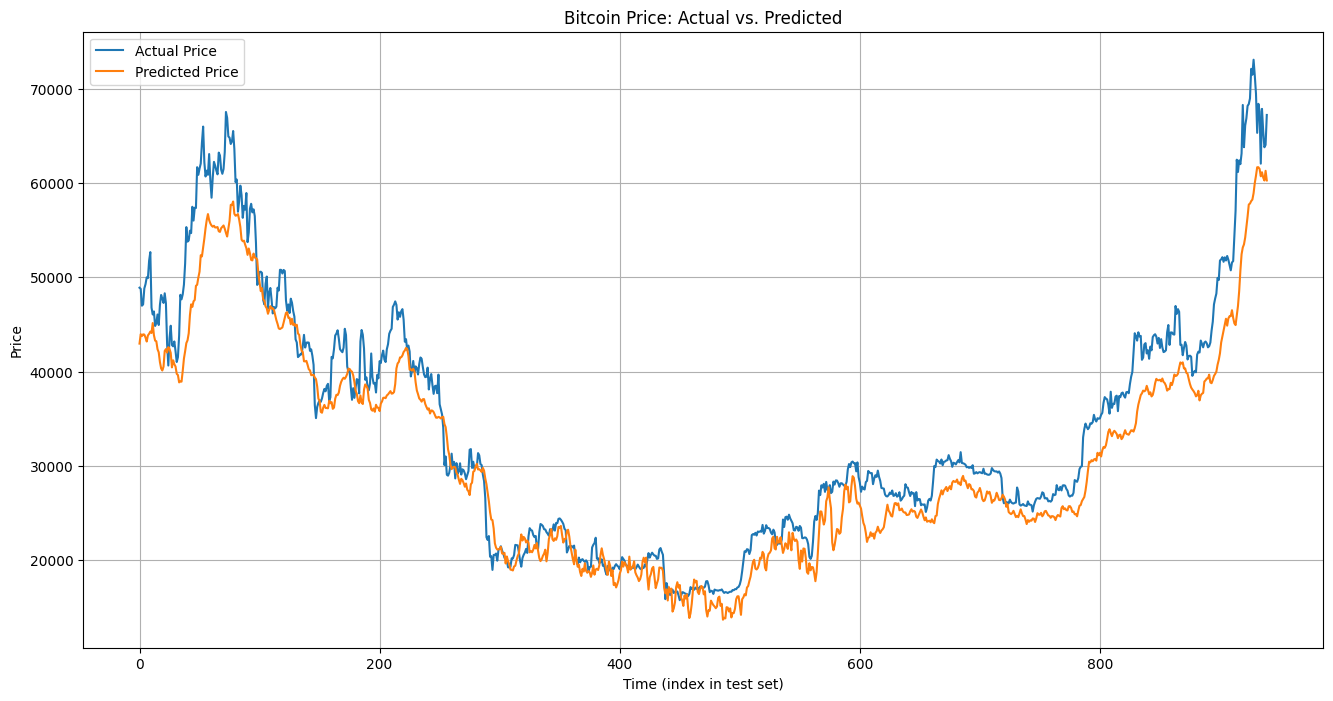

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Actual vs Predicted Price Curves ---
plt.figure(figsize=(16, 8))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(y_pred_actual, label='Predicted Price')
plt.title('Bitcoin Price: Actual vs. Predicted')
plt.xlabel('Time (index in test set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


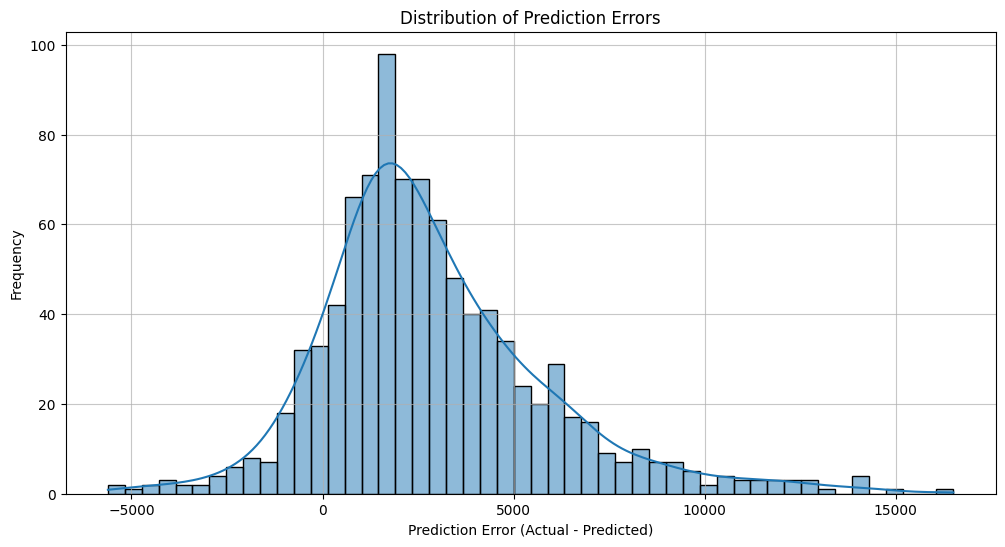

In [37]:
# --- 2. Error Distribution Plots ---
errors = y_test_actual - y_pred_actual

plt.figure(figsize=(12, 6))
sns.histplot(errors, kde=True, bins=50)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.7)
plt.show()


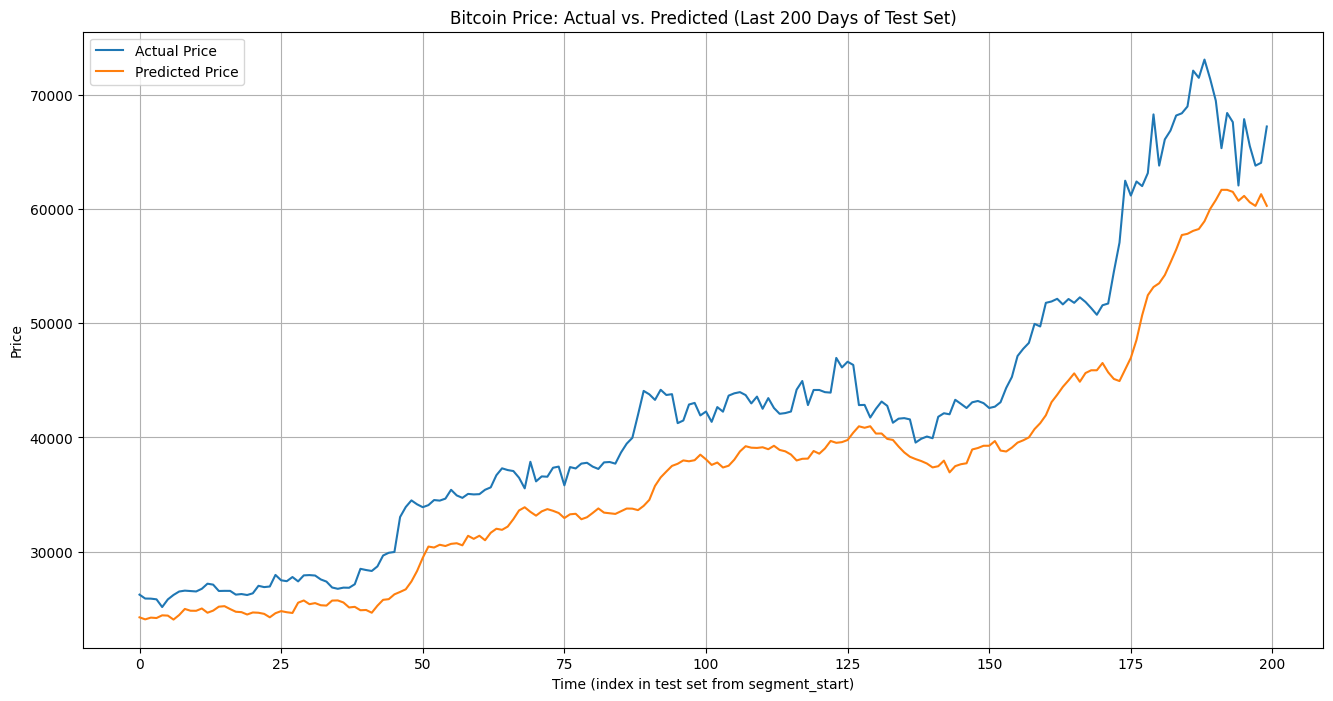

In [38]:
# --- 3. Forecast Horizon Comparison (showing a segment) ---
# Let's visualize a specific segment of the test data, e.g., the last 100 predictions
segment_start = len(y_test_actual) - 200
segment_end = len(y_test_actual)

plt.figure(figsize=(16, 8))
plt.plot(y_test_actual[segment_start:segment_end], label='Actual Price')
plt.plot(y_pred_actual[segment_start:segment_end], label='Predicted Price')
plt.title(f'Bitcoin Price: Actual vs. Predicted (Last 200 Days of Test Set)')
plt.xlabel('Time (index in test set from segment_start)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


**2. Recurrent Neural Network (RNN)**

●	Sequential dependency modeling

●	Baseline temporal model



In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Define the RNN (SimpleRNN) model
model_rnn = Sequential()
model_rnn.add(SimpleRNN(units=50, activation='relu', input_shape=(X_train_sequences.shape[1], X_train_sequences.shape[2])))
model_rnn.add(Dense(units=1)) # Output layer for regression (predicting a single value, the price)

# Compile the model
model_rnn.compile(optimizer='adam', loss='mse')

# Display model summary
print("RNN Model Summary:")
model_rnn.summary()

# Train the model
print("\nTraining the RNN model...")
# You can adjust epochs and batch_size as needed
history_rnn = model_rnn.fit(X_train_sequences, y_train_sequences, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

print("\nRNN model training complete.")

RNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)


Training the RNN model...
Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9655e-04 - val_loss: 0.0023
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.0077e-05 - val_loss: 0.0013
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.5657e-05 - val_loss: 0.0015
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.0819e-05 - val_loss: 0.0013
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.7729e-05 - val_loss: 0.0016
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.5998e-05 - val_loss: 8.4619e-04
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.8406e-05 - val_loss: 0.0011
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.4742e-05 - val_loss: 0.0016
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.5064e-05 - val_loss: 0.0017
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.4038e-05 - val_loss: 0.0015
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.2823e-05 - val_l

## Recurrent Neural Network (RNN) - Model Evaluation: Regression Metrics

In [41]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n--- Evaluating RNN (SimpleRNN) Model ---")

# Make predictions on the test set using the RNN model
y_pred_rnn_scaled = model_rnn.predict(X_test_sequences)

# Find the index of 'Price' in features_to_scale
price_col_index = features_to_scale.index('Price')

# Inverse transform y_test_sequences (actual prices) for RNN evaluation
dummy_y_test_rnn = np.zeros((len(y_test_sequences), len(features_to_scale)))
dummy_y_test_rnn[:, price_col_index] = y_test_sequences.flatten()
y_test_actual_rnn = scaler.inverse_transform(dummy_y_test_rnn)[:, price_col_index]

# Inverse transform y_pred_rnn_scaled (RNN predicted prices)
dummy_y_pred_rnn = np.zeros((len(y_pred_rnn_scaled), len(features_to_scale)))
dummy_y_pred_rnn[:, price_col_index] = y_pred_rnn_scaled.flatten()
y_pred_actual_rnn = scaler.inverse_transform(dummy_y_pred_rnn)[:, price_col_index]

# --- Regression Metrics for RNN Model ---
mae_rnn = mean_absolute_error(y_test_actual_rnn, y_pred_actual_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_test_actual_rnn, y_pred_actual_rnn))

# Define MAPE function again for clarity, though it's already defined
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero for actual values that are zero or very close to zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_rnn = mean_absolute_percentage_error(y_test_actual_rnn, y_pred_actual_rnn)

print(f"\nRNN Model (SimpleRNN) - Mean Absolute Error (MAE): {mae_rnn:.4f}")
print(f"RNN Model (SimpleRNN) - Root Mean Squared Error (RMSE): {rmse_rnn:.4f}")
print(f"RNN Model (SimpleRNN) - Mean Absolute Percentage Error (MAPE): {mape_rnn:.4f}%")


--- Evaluating RNN (SimpleRNN) Model ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

RNN Model (SimpleRNN) - Mean Absolute Error (MAE): 3369.5949
RNN Model (SimpleRNN) - Root Mean Squared Error (RMSE): 4327.1576
RNN Model (SimpleRNN) - Mean Absolute Percentage Error (MAPE): 8.6191%


## Recurrent Neural Network (RNN) - Model Evaluation: Visualization Metrics


Generating RNN Model Visualizations...


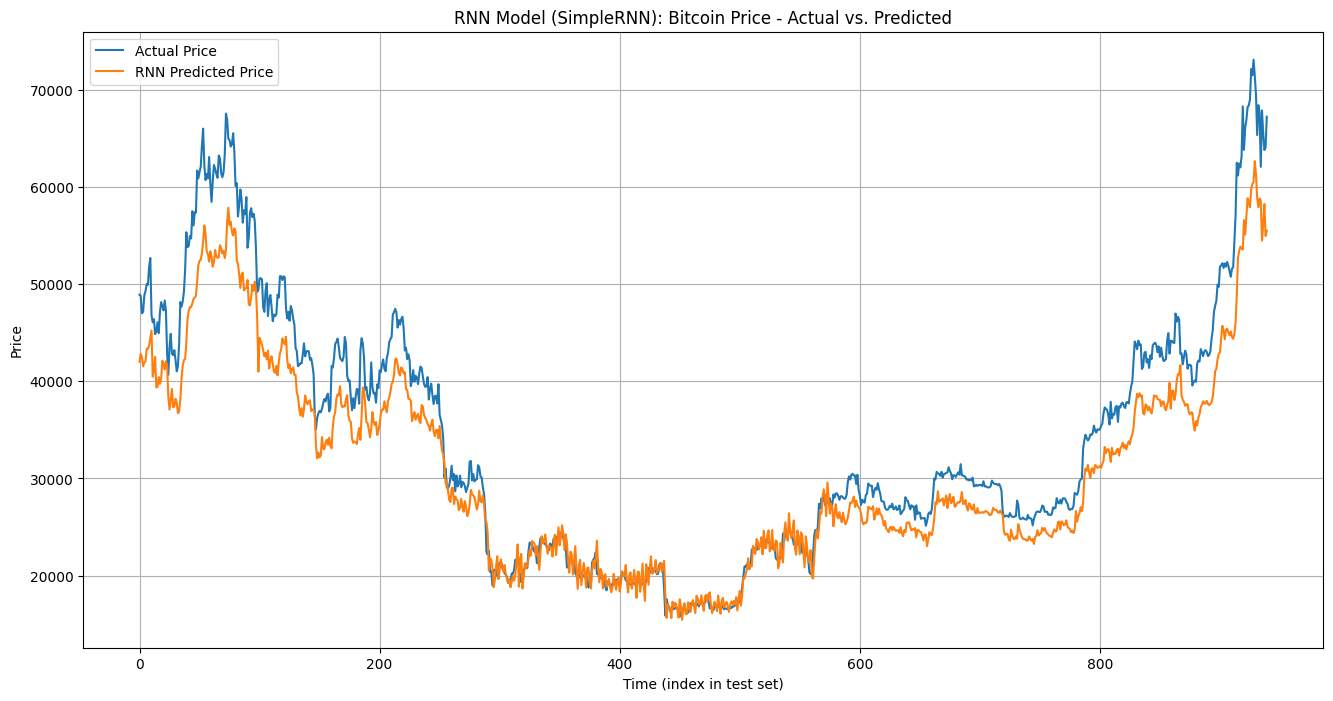

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization Metrics for RNN Model ---
print("\nGenerating RNN Model Visualizations...")

# 1. Actual vs Predicted Price Curves
plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_rnn, label='Actual Price')
plt.plot(y_pred_actual_rnn, label='RNN Predicted Price')
plt.title('RNN Model (SimpleRNN): Bitcoin Price - Actual vs. Predicted')
plt.xlabel('Time (index in test set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

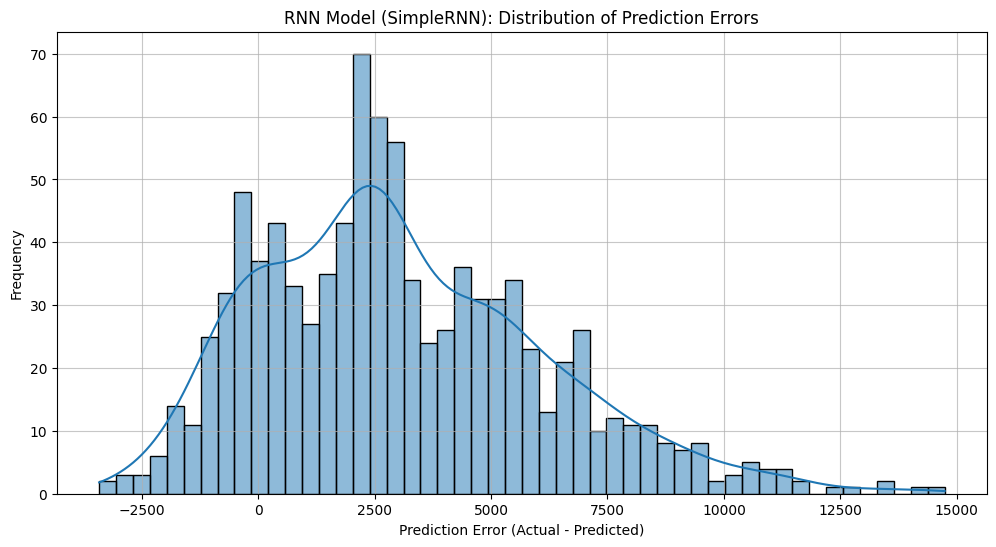

In [43]:
# 2. Error Distribution Plots
errors_rnn = y_test_actual_rnn - y_pred_actual_rnn

plt.figure(figsize=(12, 6))
sns.histplot(errors_rnn, kde=True, bins=50)
plt.title('RNN Model (SimpleRNN): Distribution of Prediction Errors')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.7)
plt.show()

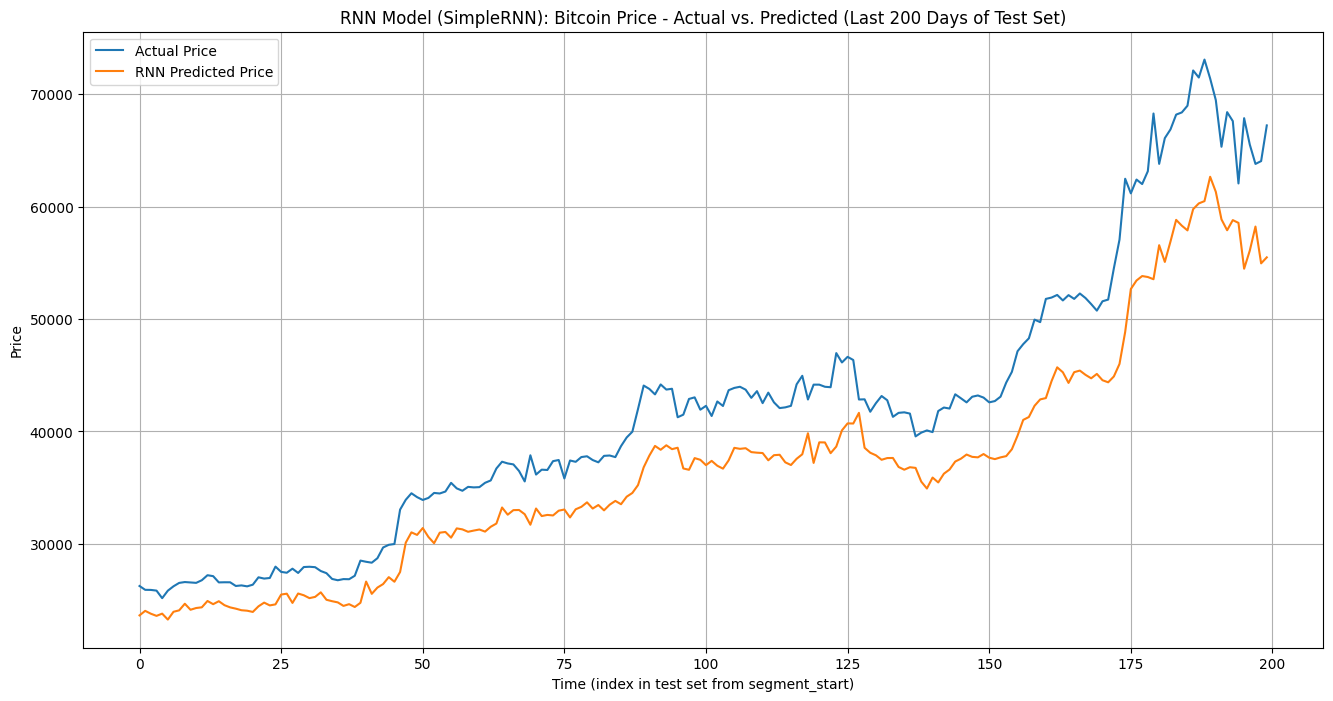

RNN model evaluation complete.


In [44]:
# 3. Forecast Horizon Comparison (showing a segment)
segment_start = len(y_test_actual_rnn) - 200 # Last 200 days
segment_end = len(y_test_actual_rnn)

plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_rnn[segment_start:segment_end], label='Actual Price')
plt.plot(y_pred_actual_rnn[segment_start:segment_end], label='RNN Predicted Price')
plt.title(f'RNN Model (SimpleRNN): Bitcoin Price - Actual vs. Predicted (Last 200 Days of Test Set)')
plt.xlabel('Time (index in test set from segment_start)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

print("RNN model evaluation complete.")

**3.Long Short-Term Memory (LSTM)**

●	Handles long-term dependencies

●	Reduces vanishing gradient problem



In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, activation='relu', input_shape=(X_train_sequences.shape[1], X_train_sequences.shape[2])))
model_lstm.add(Dense(units=1)) # Output layer for regression (predicting a single value, the price)

# Compile the model
model_lstm.compile(optimizer='adam', loss='mse')

# Display model summary
print("LSTM Model Summary:")
model_lstm.summary()

# Train the model
print("\nTraining the LSTM model...")
# You can adjust epochs and batch_size as needed
history_lstm = model_lstm.fit(X_train_sequences, y_train_sequences, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

print("\nLSTM model training complete.")

LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)


Training the LSTM model...
Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 2.6428e-04 - val_loss: 0.0014
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 3.4981e-05 - val_loss: 0.0020
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.8673e-05 - val_loss: 0.0019
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.4851e-05 - val_loss: 0.0025
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.4416e-05 - val_loss: 0.0019
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 2.2992e-05 - val_loss: 0.0013
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.0957e-05 - val_loss: 0.0014
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.0064e-05 - val_loss: 0.0013
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.8221e-05 - val_loss: 0.0010
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.9712e-05 - val_loss: 0.0015
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 1.9012e-05 - val_loss

## Long Short-Term Memory (LSTM) - Model Evaluation: Regression Metrics

In [46]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n--- Evaluating LSTM Model ---")

# Make predictions on the test set using the LSTM model
y_pred_lstm_scaled = model_lstm.predict(X_test_sequences)

# Find the index of 'Price' in features_to_scale
price_col_index = features_to_scale.index('Price')

# Inverse transform y_test_sequences (actual prices) for LSTM evaluation
dummy_y_test_lstm = np.zeros((len(y_test_sequences), len(features_to_scale)))
dummy_y_test_lstm[:, price_col_index] = y_test_sequences.flatten()
y_test_actual_lstm = scaler.inverse_transform(dummy_y_test_lstm)[:, price_col_index]

# Inverse transform y_pred_lstm_scaled (LSTM predicted prices)
dummy_y_pred_lstm = np.zeros((len(y_pred_lstm_scaled), len(features_to_scale)))
dummy_y_pred_lstm[:, price_col_index] = y_pred_lstm_scaled.flatten()
y_pred_actual_lstm = scaler.inverse_transform(dummy_y_pred_lstm)[:, price_col_index]

# --- Regression Metrics for LSTM Model ---
mae_lstm = mean_absolute_error(y_test_actual_lstm, y_pred_actual_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual_lstm, y_pred_actual_lstm))

# Define MAPE function (if not already defined or to ensure it's available)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_lstm = mean_absolute_percentage_error(y_test_actual_lstm, y_pred_actual_lstm)

print(f"\nLSTM Model - Mean Absolute Error (MAE): {mae_lstm:.4f}")
print(f"LSTM Model - Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"LSTM Model - Mean Absolute Percentage Error (MAPE): {mape_lstm:.4f}%")


--- Evaluating LSTM Model ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

LSTM Model - Mean Absolute Error (MAE): 5756.9652
LSTM Model - Root Mean Squared Error (RMSE): 7392.4312
LSTM Model - Mean Absolute Percentage Error (MAPE): 14.3479%


## Long Short-Term Memory (LSTM) - Model Evaluation: Visualization Metrics


Generating LSTM Model Visualizations...


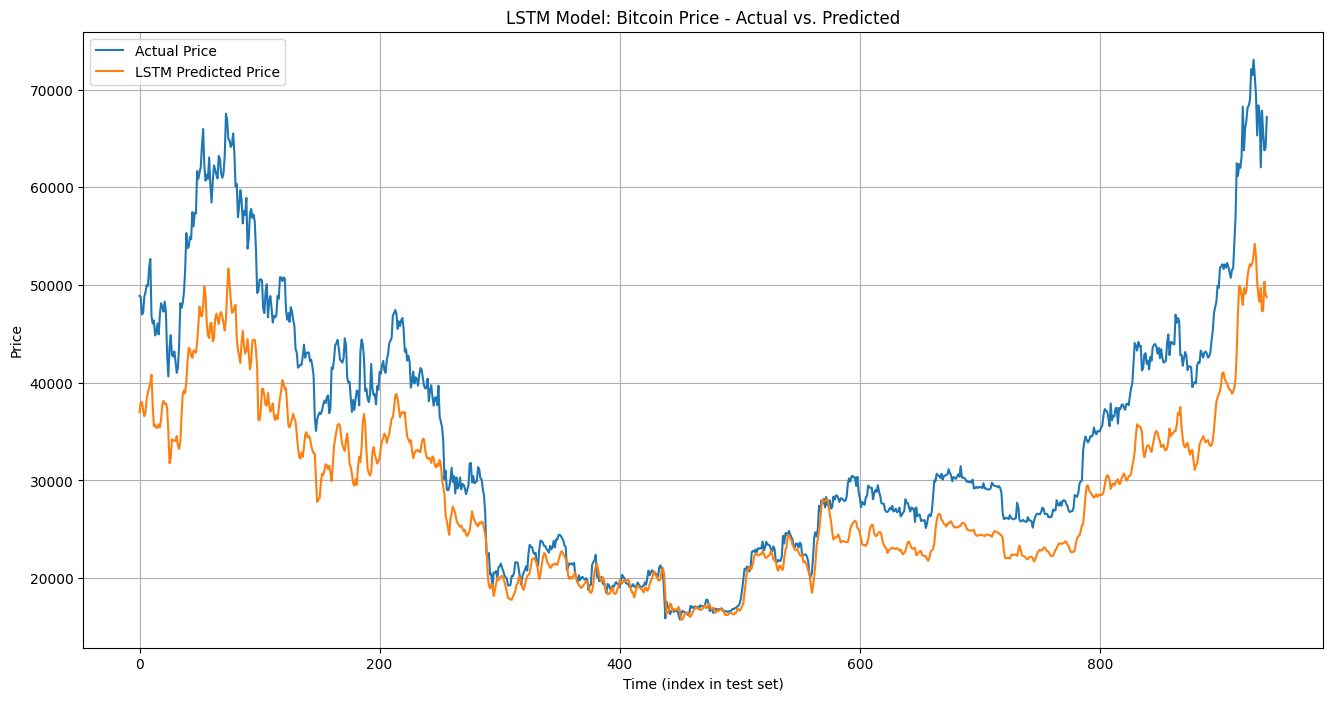

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization Metrics for LSTM Model ---
print("\nGenerating LSTM Model Visualizations...")

# 1. Actual vs Predicted Price Curves
plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_lstm, label='Actual Price')
plt.plot(y_pred_actual_lstm, label='LSTM Predicted Price')
plt.title('LSTM Model: Bitcoin Price - Actual vs. Predicted')
plt.xlabel('Time (index in test set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

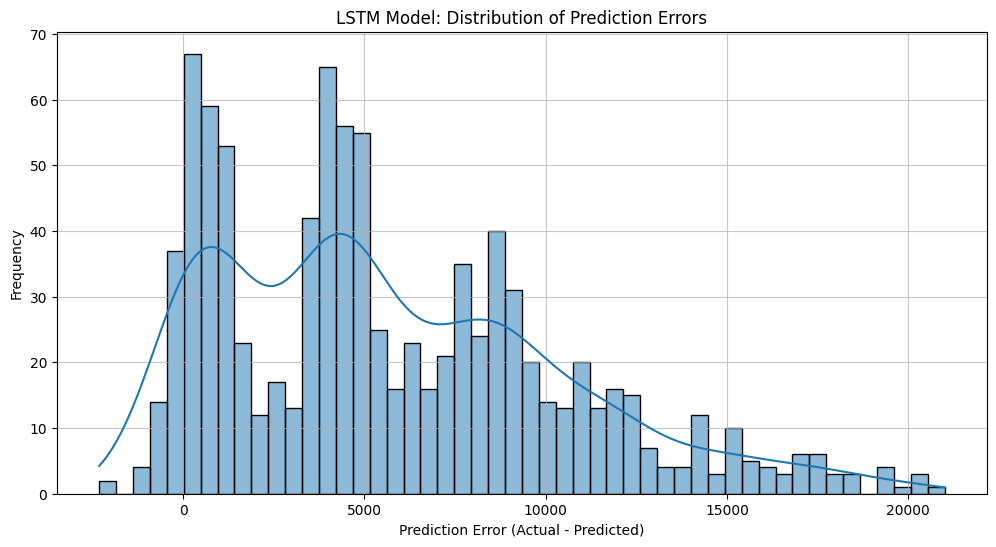

In [48]:
# 2. Error Distribution Plots
errors_lstm = y_test_actual_lstm - y_pred_actual_lstm

plt.figure(figsize=(12, 6))
sns.histplot(errors_lstm, kde=True, bins=50)
plt.title('LSTM Model: Distribution of Prediction Errors')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.7)
plt.show()

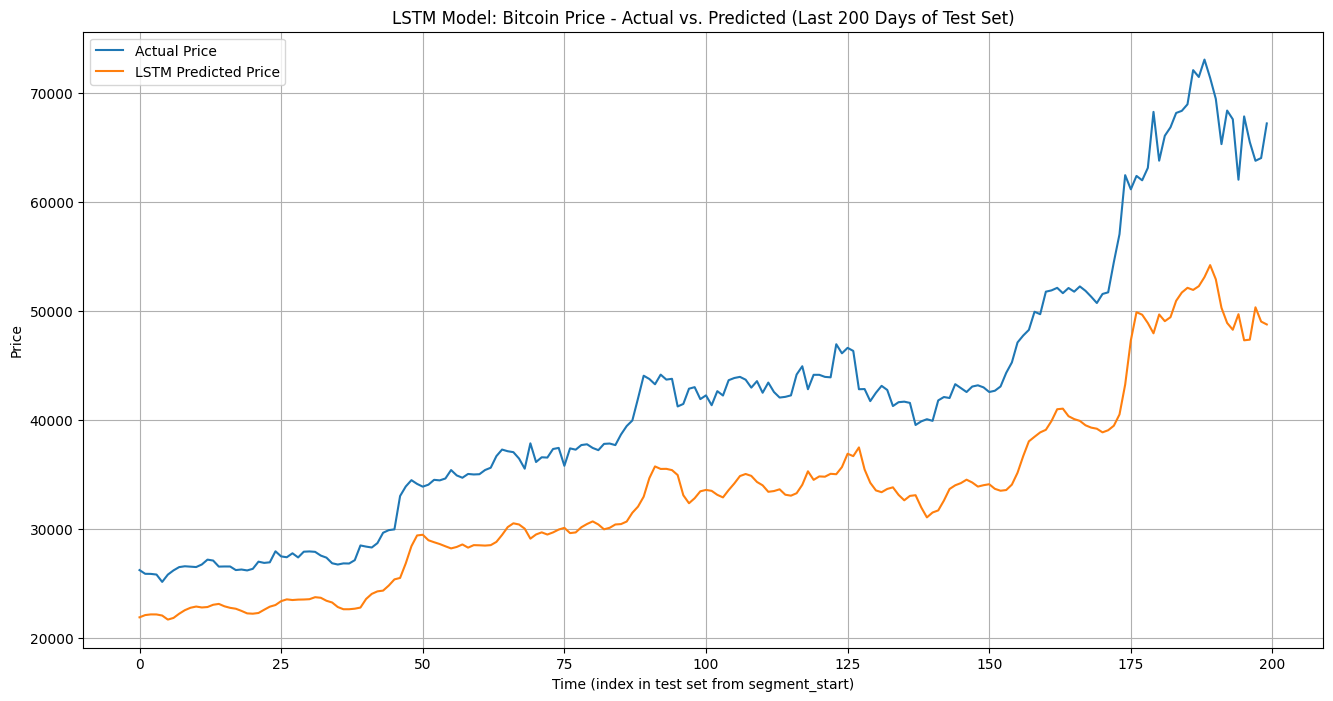

LSTM model evaluation complete.


In [49]:
# 3. Forecast Horizon Comparison (showing a segment)
segment_start = len(y_test_actual_lstm) - 200 # Last 200 days
segment_end = len(y_test_actual_lstm)

plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_lstm[segment_start:segment_end], label='Actual Price')
plt.plot(y_pred_actual_lstm[segment_start:segment_end], label='LSTM Predicted Price')
plt.title(f'LSTM Model: Bitcoin Price - Actual vs. Predicted (Last 200 Days of Test Set)')
plt.xlabel('Time (index in test set from segment_start)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

print("LSTM model evaluation complete.")

**4. Transformer (Time-Series Attention)**

●	Self-attention mechanism

●	Captures global dependencies

●	Advanced architecture for long sequences



In [51]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Define Transformer-specific hyperparameters
embed_dim = 32  # Embedding size for each token
num_heads = 2   # Number of attention heads
ff_dim = 32     # Hidden layer size in feed forward network inside transformer

# Create a Transformer block as a custom layer
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False): # Changed 'training' to be optional with a default
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Create a Token and Positional Embedding layer
class TokenAndPositionalEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Dense(embed_dim) # Use Dense for numerical feature embedding
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-2] # Get sequence length
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x) # Embed features
        return x + positions

# Define the Transformer model
lookback_window = X_train_sequences.shape[1] # 60
num_features = X_train_sequences.shape[2]   # 5

inputs = layers.Input(shape=(lookback_window, num_features))
embedding_layer = TokenAndPositionalEmbedding(lookback_window, num_features, embed_dim)
x = embedding_layer(inputs)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
x = layers.GlobalAveragePooling1D()(x) # Flattening the output of the Transformer block
x = layers.Dropout(0.1)(x)
x = layers.Dense(20, activation="relu")(x)
outputs = layers.Dense(1)(x) # Output for regression

model_transformer = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
model_transformer.compile(optimizer="adam", loss="mse")

# Display model summary
print("Transformer Model Summary:")
model_transformer.summary()

# Train the model
print("\nTraining the Transformer model...")
# You might need to adjust epochs and batch_size based on your data and performance
history_transformer = model_transformer.fit(
    X_train_sequences, y_train_sequences, epochs=50, batch_size=32, verbose=1, validation_split=0.2
)

print("\nTransformer model training complete.")

Transformer Model Summary:


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 60, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_positional_embedding… │ (None, 60, 32)         │         2,112 │
│ (TokenAndPositionalEmbedding)   │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 60, 32)         │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,449 (52.54 KB)

 Trainable params: 13,449 (52.54 KB)

 Non-trainable params: 0 (0.00 B)


Training the Transformer model...
Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0377 - val_loss: 0.0690
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0045 - val_loss: 0.1257
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.0028 - val_loss: 0.0938
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0020 - val_loss: 0.0732
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0017 - val_loss: 0.0704
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0014 - val_loss: 0.0778
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0011 - val_loss: 0.0625
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 8.9037e-04 - val_loss: 0.0312
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 6.7569e-04 - val_loss: 0.0390
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 5.8840e-04 - val_loss: 0.0415
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 4.1514e-04 - val_loss: 0.0422
Epoch 12/50

#Transformer - Model Evaluation Metrics: Regression Metrics




In [52]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n--- Evaluating Transformer Model ---")

# Make predictions on the test set using the Transformer model
y_pred_transformer_scaled = model_transformer.predict(X_test_sequences)

# The scaler and price_col_index are already defined from previous cells.
# Inverse transform y_test_sequences (actual prices) for Transformer evaluation
dummy_y_test_transformer = np.zeros((len(y_test_sequences), len(features_to_scale)))
dummy_y_test_transformer[:, price_col_index] = y_test_sequences.flatten()
y_test_actual_transformer = scaler.inverse_transform(dummy_y_test_transformer)[:, price_col_index]

# Inverse transform y_pred_transformer_scaled (Transformer predicted prices)
dummy_y_pred_transformer = np.zeros((len(y_pred_transformer_scaled), len(features_to_scale)))
dummy_y_pred_transformer[:, price_col_index] = y_pred_transformer_scaled.flatten()
y_pred_actual_transformer = scaler.inverse_transform(dummy_y_pred_transformer)[:, price_col_index]

# --- Regression Metrics for Transformer Model ---
mae_transformer = mean_absolute_error(y_test_actual_transformer, y_pred_actual_transformer)
rmse_transformer = np.sqrt(mean_squared_error(y_test_actual_transformer, y_pred_actual_transformer))

# Define MAPE function (ensure it's available or redefine)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero for actual values that are zero or very close to zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_transformer = mean_absolute_percentage_error(y_test_actual_transformer, y_pred_actual_transformer)

print(f"\nTransformer Model - Mean Absolute Error (MAE): {mae_transformer:.4f}")
print(f"Transformer Model - Root Mean Squared Error (RMSE): {rmse_transformer:.4f}")
print(f"Transformer Model - Mean Absolute Percentage Error (MAPE): {mape_transformer:.4f}%")



--- Evaluating Transformer Model ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

Transformer Model - Mean Absolute Error (MAE): 15466.9610
Transformer Model - Root Mean Squared Error (RMSE): 19126.8376
Transformer Model - Mean Absolute Percentage Error (MAPE): 40.8109%


# Transformer - Model Evaluation Metrics - Visualization Metrics




Generating Transformer Model Visualizations...


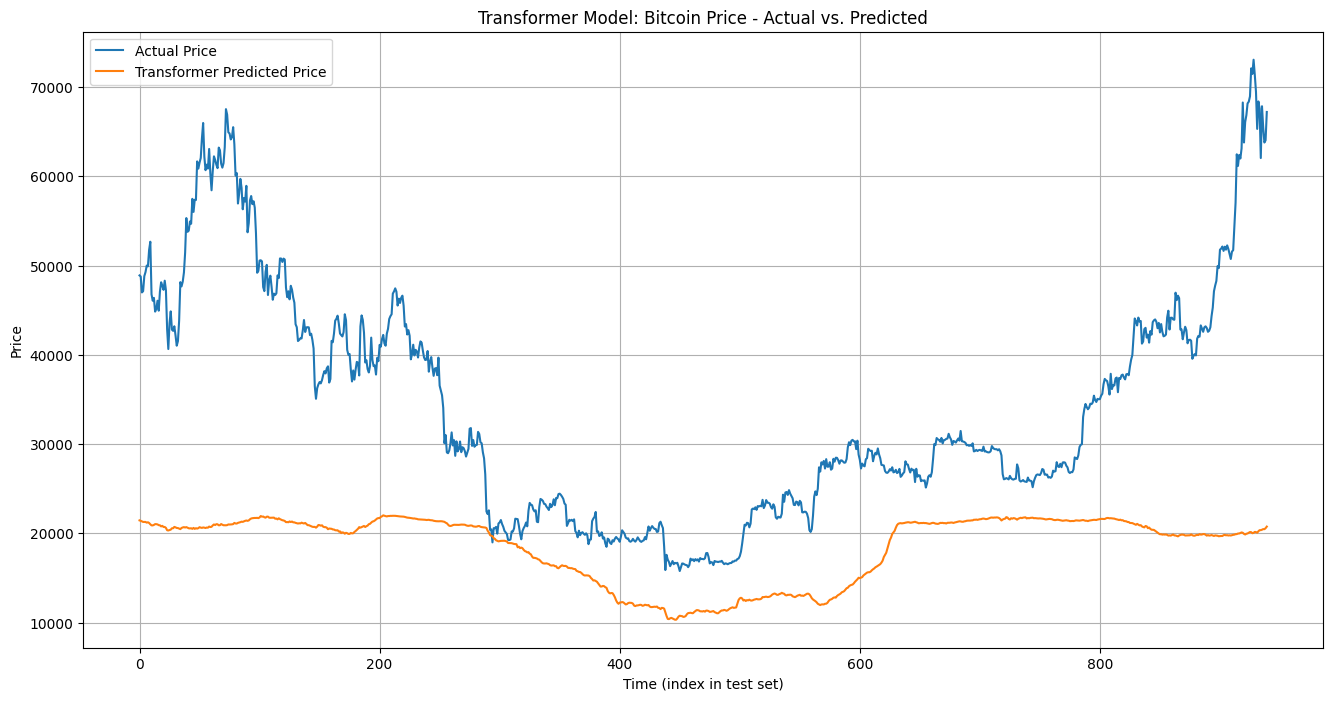

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nGenerating Transformer Model Visualizations...")

# 1. Actual vs Predicted Price Curves
plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_transformer, label='Actual Price')
plt.plot(y_pred_actual_transformer, label='Transformer Predicted Price')
plt.title('Transformer Model: Bitcoin Price - Actual vs. Predicted')
plt.xlabel('Time (index in test set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

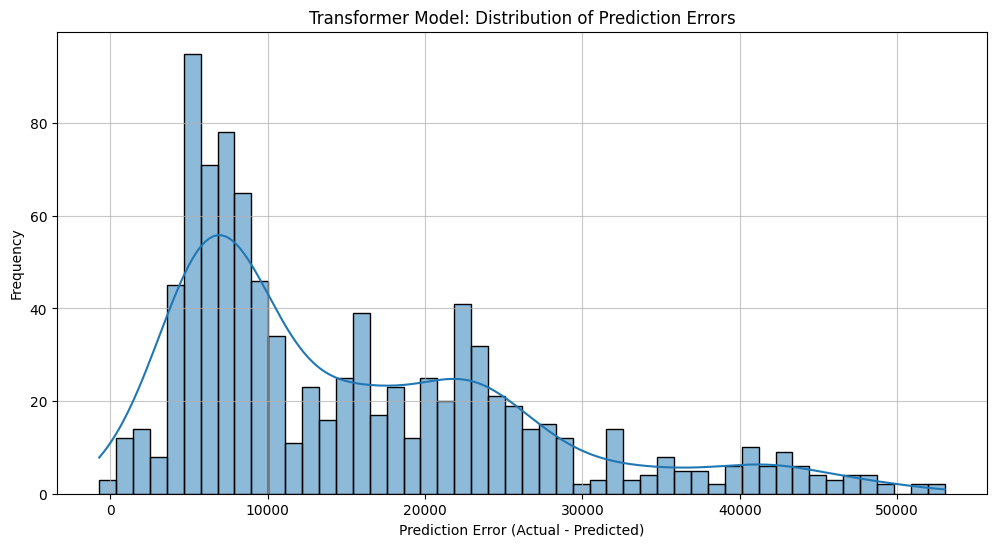

In [54]:
# 2. Error Distribution Plots
errors_transformer = y_test_actual_transformer - y_pred_actual_transformer

plt.figure(figsize=(12, 6))
sns.histplot(errors_transformer, kde=True, bins=50)
plt.title('Transformer Model: Distribution of Prediction Errors')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.7)
plt.show()

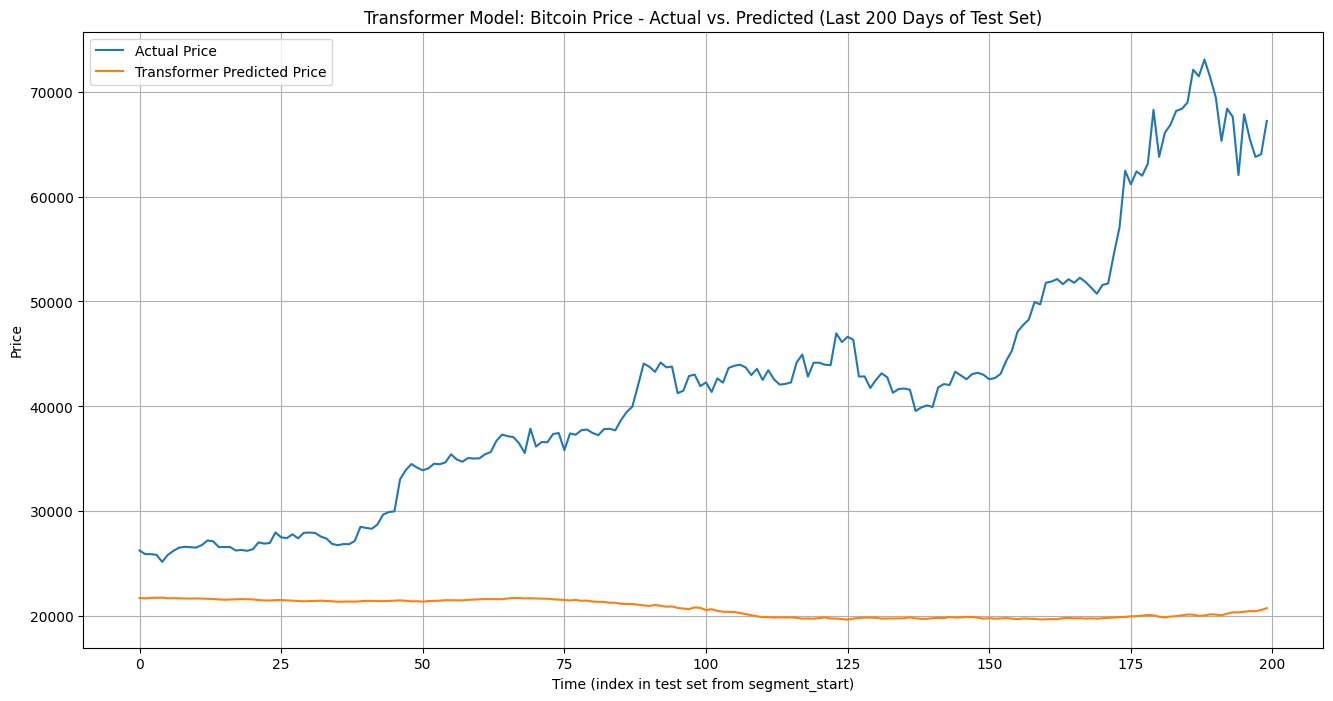

Transformer model evaluation complete.


In [55]:
# 3. Forecast Horizon Comparison (showing a segment)
segment_start = len(y_test_actual_transformer) - 200 # Last 200 days
segment_end = len(y_test_actual_transformer)

plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_transformer[segment_start:segment_end], label='Actual Price')
plt.plot(y_pred_actual_transformer[segment_start:segment_end], label='Transformer Predicted Price')
plt.title(f'Transformer Model: Bitcoin Price - Actual vs. Predicted (Last 200 Days of Test Set)')
plt.xlabel('Time (index in test set from segment_start)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

print("Transformer model evaluation complete.")

#5.GRU (Gated Recurrent Unit) model

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

print("\n--- Building GRU Model ---")

# Define the GRU model
model_gru = Sequential()
model_gru.add(GRU(units=50, activation='relu', input_shape=(X_train_sequences.shape[1], X_train_sequences.shape[2])))
model_gru.add(Dense(units=1)) # Output layer for regression (predicting a single value, the price)

# Compile the model
model_gru.compile(optimizer='adam', loss='mse')

# Display model summary
print("GRU Model Summary:")
model_gru.summary()

# Train the model
print("\nTraining the GRU model...")
# You can adjust epochs and batch_size as needed
history_gru = model_gru.fit(X_train_sequences, y_train_sequences, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

print("\nGRU model training complete.")


--- Building GRU Model ---
GRU Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         8,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,601 (33.60 KB)

 Trainable params: 8,601 (33.60 KB)

 Non-trainable params: 0 (0.00 B)


Training the GRU model...
Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 6.2195e-04 - val_loss: 0.0076
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 2.4421e-05 - val_loss: 0.0049
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.8499e-05 - val_loss: 0.0051
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.6531e-05 - val_loss: 0.0054
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 1.5604e-05 - val_loss: 0.0049
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.4714e-05 - val_loss: 0.0056
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 1.4658e-05 - val_loss: 0.0049
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 1.3885e-05 - val_loss: 0.0045
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.3753e-05 - val_loss: 0.0047
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.2347e-05 - val_loss: 0.0046
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 1.2982e-05 - val_loss:

#GRU (Gated Recurrent Unit) mode - Model Evaluation Metrics: Regression Metrics

In [57]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n--- Evaluating GRU Model ---")

# Make predictions on the test set using the GRU model
y_pred_gru_scaled = model_gru.predict(X_test_sequences)

# The scaler and price_col_index are already defined from previous cells.
# Inverse transform y_test_sequences (actual prices) for GRU evaluation
dummy_y_test_gru = np.zeros((len(y_test_sequences), len(features_to_scale)))
dummy_y_test_gru[:, price_col_index] = y_test_sequences.flatten()
y_test_actual_gru = scaler.inverse_transform(dummy_y_test_gru)[:, price_col_index]

# Inverse transform y_pred_gru_scaled (GRU predicted prices)
dummy_y_pred_gru = np.zeros((len(y_pred_gru_scaled), len(features_to_scale)))
dummy_y_pred_gru[:, price_col_index] = y_pred_gru_scaled.flatten()
y_pred_actual_gru = scaler.inverse_transform(dummy_y_pred_gru)[:, price_col_index]

# --- Regression Metrics for GRU Model ---
mae_gru = mean_absolute_error(y_test_actual_gru, y_pred_actual_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test_actual_gru, y_pred_actual_gru))

# Define MAPE function (ensure it's available or redefine)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero for actual values that are zero or very close to zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_gru = mean_absolute_percentage_error(y_test_actual_gru, y_pred_actual_gru)

print(f"\nGRU Model - Mean Absolute Error (MAE): {mae_gru:.4f}")
print(f"GRU Model - Root Mean Squared Error (RMSE): {rmse_gru:.4f}")
print(f"GRU Model - Mean Absolute Percentage Error (MAPE): {mape_gru:.4f}%")


--- Evaluating GRU Model ---
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

GRU Model - Mean Absolute Error (MAE): 5702.5634
GRU Model - Root Mean Squared Error (RMSE): 7149.3983
GRU Model - Mean Absolute Percentage Error (MAPE): 14.5026%


## GRU Model - Model Evaluation: Visualization Metrics


Generating GRU Model Visualizations...


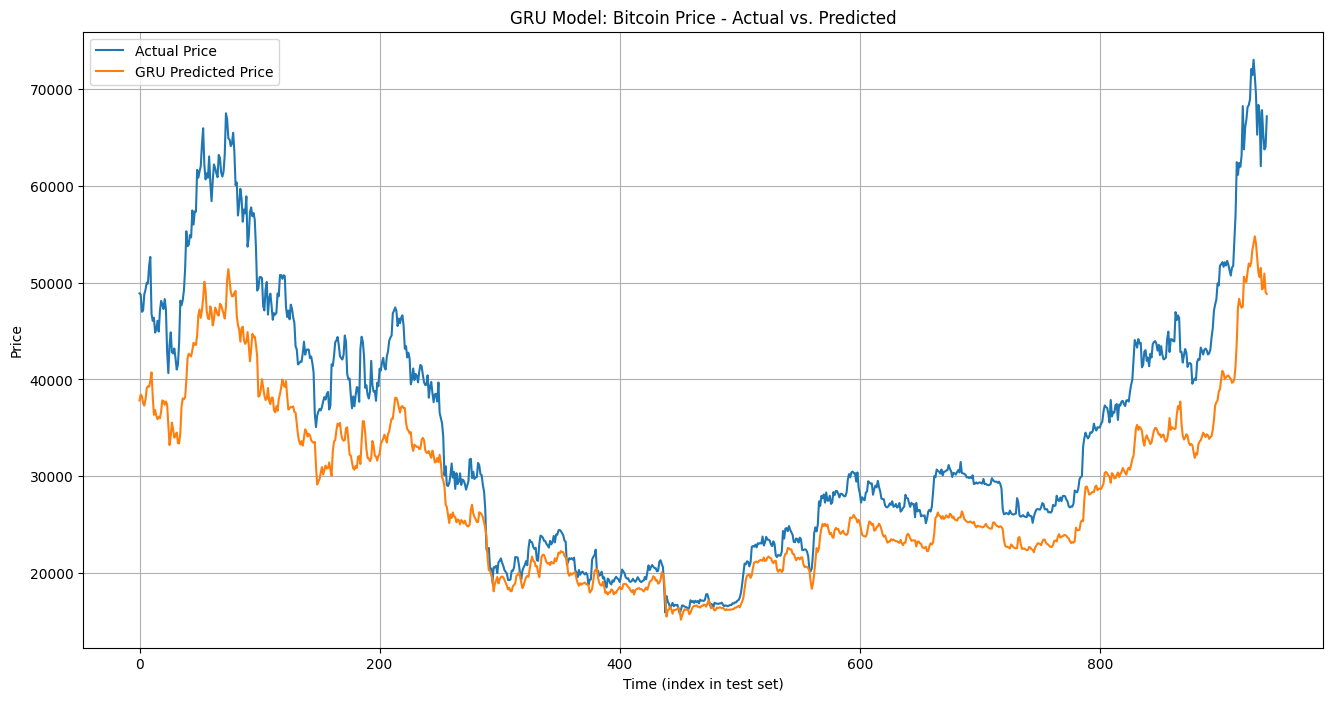

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nGenerating GRU Model Visualizations...")

# 1. Actual vs Predicted Price Curves
plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_gru, label='Actual Price')
plt.plot(y_pred_actual_gru, label='GRU Predicted Price')
plt.title('GRU Model: Bitcoin Price - Actual vs. Predicted')
plt.xlabel('Time (index in test set)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

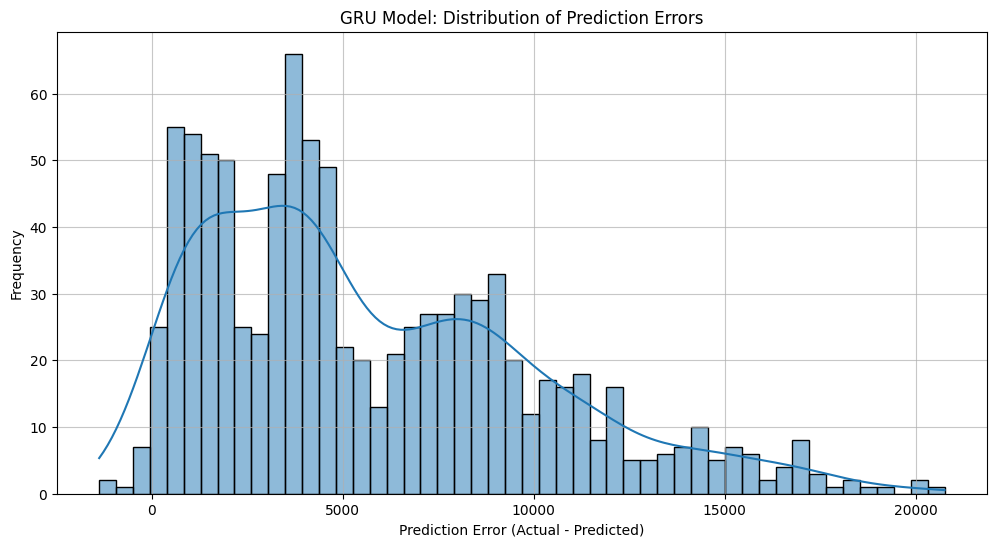

In [59]:
# 2. Error Distribution Plots
errors_gru = y_test_actual_gru - y_pred_actual_gru

plt.figure(figsize=(12, 6))
sns.histplot(errors_gru, kde=True, bins=50)
plt.title('GRU Model: Distribution of Prediction Errors')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.7)
plt.show()

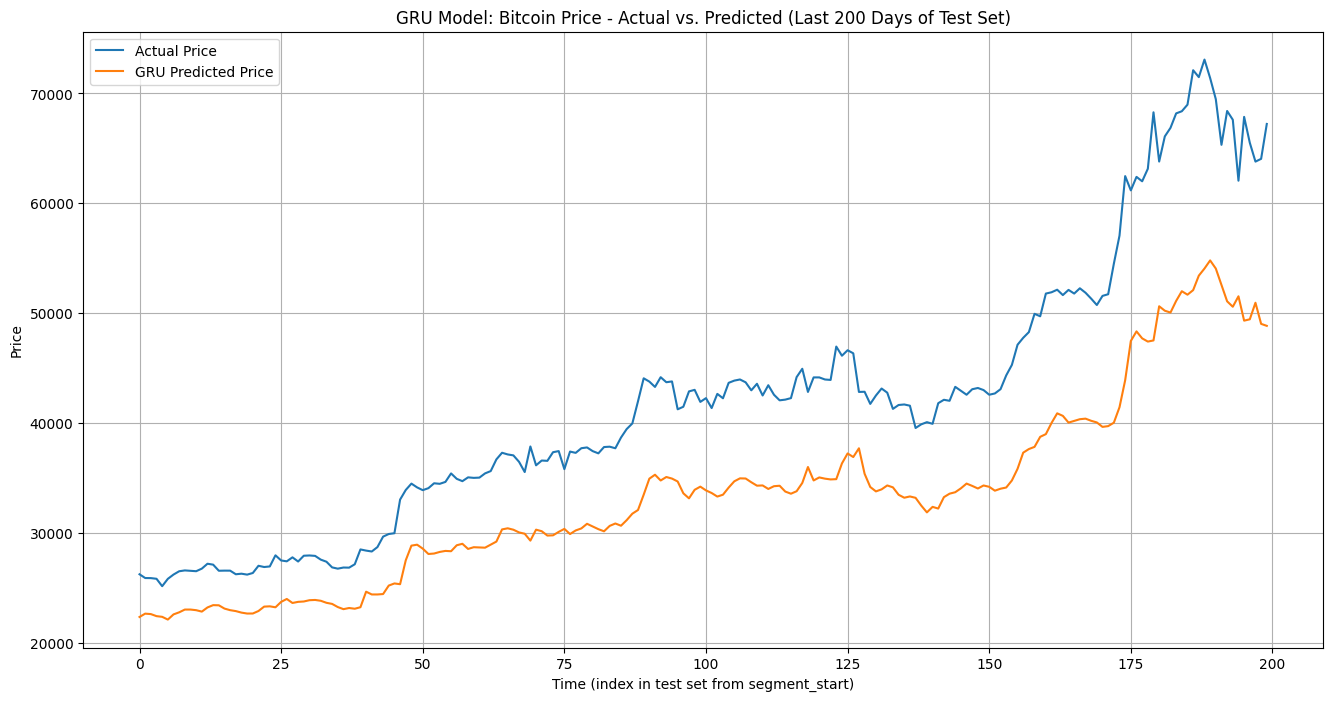

GRU model evaluation complete.


In [60]:
# 3. Forecast Horizon Comparison (showing a segment)
segment_start_gru = len(y_test_actual_gru) - 200 # Last 200 days
segment_end_gru = len(y_test_actual_gru)

plt.figure(figsize=(16, 8))
plt.plot(y_test_actual_gru[segment_start_gru:segment_end_gru], label='Actual Price')
plt.plot(y_pred_actual_gru[segment_start_gru:segment_end_gru], label='GRU Predicted Price')
plt.title(f'GRU Model: Bitcoin Price - Actual vs. Predicted (Last 200 Days of Test Set)')
plt.xlabel('Time (index in test set from segment_start)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

print("GRU model evaluation complete.")

#Comparision of model

In [61]:
import pandas as pd

# Create a dictionary to store the metrics
metrics = {
    'Model': ['1D-CNN', 'SimpleRNN', 'LSTM', 'Transformer', 'GRU'],
    'MAE': [mae, mae_rnn, mae_lstm, mae_transformer, mae_gru],
    'RMSE': [rmse, rmse_rnn, rmse_lstm, rmse_transformer, rmse_gru],
    'MAPE (%)': [mape, mape_rnn, mape_lstm, mape_transformer, mape_gru]
}

# Create a DataFrame from the metrics dictionary
metrics_df = pd.DataFrame(metrics)

# Sort by MAE for better comparison (optional)
metrics_df = metrics_df.sort_values(by='MAE').reset_index(drop=True)

print("\n--- Model Evaluation Metrics Comparison ---")
display(metrics_df.round(2))


--- Model Evaluation Metrics Comparison ---


,Model,MAE,RMSE,MAPE (%)
0,1D-CNN,3183.57,4154.25,8.89
1,SimpleRNN,3369.59,4327.16,8.62
2,GRU,5702.56,7149.40,14.50
3,LSTM,5756.97,7392.43,14.35
4,Transformer,15466.96,19126.84,40.81


#Save Evaluation comparison metrics into CSV file

In [63]:
csv_filename = 'model_evaluation_comparison.csv'
metrics_df.to_csv(csv_filename, index=False)
print(f"Evaluation comparison saved to {csv_filename}")

Evaluation comparison saved to model_evaluation_comparison.csv
